## CCBD Project 6 — Cloud Bill Estimator: Analysis
### **Variant 6**: Cost ("cloud bill") estimator for S3 object storage.
### This notebook analyses results.csv produced by bench.py and provides cost breakdowns, performance comparisons, and concrete recommendations.

In [2]:
# imports and reading data
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
df = pd.read_csv('results.csv')


In [ ]:
SIZES = ['S', 'M', 'L']
COST_COLS = ['storage_chf', 'requests_chf', 'transfer_chf']

def plot_cost(df, filter_fn, x_col, title, palette):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    for i, size in enumerate(SIZES):
        subset = filter_fn(df[df['label'] == size].copy())
        if not subset.empty:
            subset.set_index(x_col)[COST_COLS].plot(
                kind='bar', stacked=True, ax=axes[i], color=palette, legend=False
            )
            axes[i].set_title(f'Size {size}', fontsize=12)
            axes[i].set_ylabel('CHF')
            axes[i].set_xlabel('')
            axes[i].tick_params(axis='x', rotation=0)
            axes[i].grid(axis='y', linestyle='--', alpha=0.4)
        else:
            axes[i].set_title(f'Size {size} (No Data)')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Cost Breakdown', loc='center right', bbox_to_anchor=(1, 0.5))
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
    plt.show()

def filter_format(d):
    return d[
        (d['n_files'] == 1) &
        ((d['variant'] == 'raw') | ((d['variant'] == 'parquet') & (d['compression'] == 'none')))
    ]

def filter_compression(d):
    return d[
        (d['variant'] == 'parquet') &
        d['compression'].notna() &
        (d['compression'] != 'none')
    ]

def filter_segmentation(d):
    sub = d[
        ((d['variant'] == 'parquet') & (d['compression'] == 'none')) |
        (d['variant'] == 'parquet_small')
    ].copy()
    sub['sizing'] = sub['n_files'].apply(lambda x: 'Small' if x > 1 else 'Compact')
    return sub

def filter_partition(d):
    return d[
        ((d['variant'] == 'parquet') & (d['compression'] == 'none')) |
        (d['variant'] == 'parquet_partitioned')
    ]

# i wanna show the query time for the different design choices too, gives good insights
def plot_query_time(df, filter_fn, x_col, title, palette):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, size in enumerate(SIZES):
        subset = filter_fn(df[df['label'] == size].copy())
        if not subset.empty:
            subset = subset.set_index(x_col)
            axes[i].bar(subset.index, subset['query_time_s'], color=palette)
            axes[i].set_title(f'Size {size}')
            axes[i].set_ylabel('Query Time (s)')
            axes[i].grid(axis='y', linestyle='--', alpha=0.4)
            axes[i].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()


# keeping it consistent
blue_palette   = ['#2980b9', '#3498db', '#aed6f1']
orange_palette = ['#d35400', '#e67e22', '#f5b041']
green_palette  = ['#27ae60', '#2ecc71', '#abebc6']
purple_palette = ['#8e44ad', '#9b59b6', '#d7bde2']

plot_cost(df,filter_format,'variant','Comparison 1: CSV vs Parquet',blue_palette)
plot_cost(df,filter_compression, 'compression','Comparison 2: Snappy vs ZSTD',orange_palette)
plot_cost(df,filter_segmentation,'sizing','Comparison 3: File Segmentation',green_palette)
plot_cost(df,filter_partition,   'variant','Comparison 4: Partitioned vs Flat',purple_palette)

plot_query_time(df,filter_format,'variant','Query Time: CSV vs Parquet',blue_palette)
plot_query_time(df,filter_compression,'compression','Query Time: Snappy vs ZSTD',orange_palette)
plot_query_time(df,filter_segmentation,'sizing','Query Time: Small vs Compact',green_palette)
plot_query_time(df,filter_partition,'variant','Query Time: Partitioned vs Flat',purple_palette)

raw_mb = df[df['variant'] == 'raw'].set_index('label')['stored_mb']
df['savings_pct'] = df.apply(
    lambda r: round((1 - r['stored_mb'] / raw_mb[r['label']]) * 100, 1), axis=1
)
df['compression_ratio'] = df.apply(
    lambda r: round(raw_mb[r['label']] / r['stored_mb'], 2), axis=1
)

print(df[['label', 'variant', 'compression', 'stored_mb', 'compression_ratio', 'savings_pct']]
      .sort_values(['label', 'compression_ratio'], ascending=[True, False])
      .to_string(index=False))


In [ ]:
df['transfer_pct']  = (df['transfer_chf']  / df['total_chf'] * 100).round(1)
df['requests_pct']  = (df['requests_chf']  / df['total_chf'] * 100).round(1)
df['storage_pct']   = (df['storage_chf']   / df['total_chf'] * 100).round(1)

print(df[['label', 'variant', 'compression', 'storage_pct', 'requests_pct', 'transfer_pct', 'total_chf']]
      .sort_values('total_chf')
      .to_string(index=False))

Transfer (egress) accounts for >80% of total cost at all sizes and variants. Storage is secondary (~18%). Requests are negligible (<2%) except for parquet_partitioned, where 60 LIST operations push requests to ~0.5%. The dominant cost lever is therefore compression — anything that reduces bytes transferred directly reduces the bill.


### Anomaly: parquet_partitioned inflates storage

At size M, parquet_partitioned stores 2270 MB — nearly 2× more than raw CSV (1217 MB). At L it stores 9081 MB vs 4871 MB raw. This is because 120 Hive partition folders each contain separate row-group footer metadata, duplicating schema and statistics overhead across every file. Combined with 60 LIST requests (one per partition prefix), this variant is both the most expensive and the slowest at query time (41s at L vs 2s for parquet_zstd).

## Query Performance (predicate pushdown scan time)
All variants run the same filter: region=Europe, ts in [2022-01-01, 2023-01-01], groupby event_type

Despite being partitioned by date, parquet_partitioned is the *slowest* variant at M (9.3s) and L (41.4s), because 120 small partition files create a high amount of open/close.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='dl_mbps',
    y='total_chf',
    hue='variant',
    style='label',
    s=200,
    alpha=0.8,
    palette='viridis',
    ax=ax
)

ax.set_title('Download Speed vs. Total Cost', fontsize=16, fontweight='bold')
ax.set_xlabel('Download Speed (MB/s)', fontsize=13)
ax.set_ylabel('Total Cost (CHF)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Variant / Size', bbox_to_anchor=(1.05, 1), loc='upper left')

for i in range(df.shape[0]):
    label = f"{df.label.iloc[i]}-{df.compression.fillna('–').iloc[i]}"
    ax.text(df.dl_mbps.iloc[i] + 0.5, df.total_chf.iloc[i], label, fontsize=8, va='center')

plt.tight_layout()
plt.show()

The scatter plot reveals two clear clusters. Compressed single-file variants
(`parquet_snappy`, `parquet_zstd`) occupy the bottom-right — high download speed
with low cost — making them the optimal choice. Uncompressed and partitioned
variants cluster in the bottom-left (slow downloads, low cost for small sizes)
or top-left (`parquet_partitioned` at L: 1.0 CHF at only ~31 MB/s), representing
the worst trade-off. Raw CSV at L sits mid-right (0.54 CHF, ~31 MB/s) — fast
but expensive due to its large file size. The ideal region is **bottom-right**:
fast downloads driven by small compressed files reducing egress bytes.

## Recommendations

| Use Case | Best Choice | Reason |
|---|---|---|
| Minimize cost | `parquet_zstd` | 73% smaller than raw -> 73% less egress cost |
| Fastest query | `parquet_small` | Best query time at M/L; no per-file open overhead |
| Avoid | `parquet_partitioned` | Storage inflation + slow queries at scale |
| Interoperability | `raw` CSV | No compression CPU, universally readable |

### Threats to validity
- Single-run measurements — no repeat trials or confidence intervals
- Network conditions varied between runs (local → AWS us-east)
- Storage cost modelled as 1 month of snapshot, not continuous
- Request counts are lower bounds (S3 internal retries not counted)

In [ ]:
df_ols = pd.read_csv('results.csv')

df_ols['label']   = pd.Categorical(df_ols['label'],   categories=['S', 'M', 'L'],                                                           ordered=True)
df_ols['variant'] = pd.Categorical(df_ols['variant'], categories=['raw', 'parquet', 'parquet_small', 'parquet_partitioned'], ordered=True)

df_encoded = pd.get_dummies(df_ols, columns=['label', 'variant', 'compression'], drop_first=True)

X = df_encoded[[
    'stored_mb',
    'n_files',
    'label_M',
    'label_L',
    'variant_parquet',
    'variant_parquet_small',
    'variant_parquet_partitioned',
    'compression_snappy',
    'compression_zstd'
]]

y = df_encoded['total_chf']
X = sm.add_constant(X)

model = sm.OLS(y, X.astype(float)).fit()
print(model.summary())

### OLS Interpretation

We fit an OLS as a sanity check to confirm which variables drive cost in the pricing formula.

`stored_mb` has the largest positive coefficient (= 0.0001 per MB) and is the
only predictor significant at p < 0.001, confirming that file size — driven by
compression choice - is the primary cost driver. `n_files` is the second
significant predictor (coef = 1.2e-05, p < 0.001), capturing the per-request
overhead that penalises `parquet_small` (up to 1000 files) and
`parquet_partitioned` (60 LIST operations).

`compression_zstd` carries the largest negative coefficient among the compression
dummies (coef = -7e-05), consistent with the 73% size reduction over raw CSV
observed in the storage analysis. `variant_parquet_partitioned` has a positive
coefficient (coef = 0.0002) reflecting its storage inflation — at size L it
stores 9081 MB vs 4871 MB for raw.

R² = 1.000 with n=18 is expected: the cost formula is deterministic, so the
model is reconstructing arithmetic rather than discovering a statistical pattern.
P-values and confidence intervals should not be interpreted as inferential.



# Variant 2, makes more sense story wise

In [9]:
# 1. Create a unique name for each variant
# If compression exists, append it. Otherwise, keep the original variant name.

df['full_variant'] = df.apply(
    lambda x: f"{x['variant']}_{x['compression']}" if pd.notnull(x['compression']) and x['compression'] != '' 
    else x['variant'], axis=1
)

# 2. Calculate the Efficiency Index (Cost * Time)
df['efficiency_index'] = df['total_chf'] * df['query_time_s']

# 3. Create the baseline dictionary using the 'raw' variant for each size
baselines = df[df['variant'] == 'raw'].set_index('label')['efficiency_index'].to_dict()

# 4. Map baselines and calculate the Improvement Factor
df['baseline_efficiency'] = df['label'].map(baselines)
df['improvement_factor'] = df['baseline_efficiency'] / df['efficiency_index']

# 5. Display the results for all 3 sizes, sorted by performance
# We use full_variant now so you can see 'parquet_snappy' vs 'parquet_partitioned'
summary = df.sort_values(['label', 'improvement_factor'], ascending=[True, False])

# Define the columns to display
cols = ['label', 'full_variant', 'total_chf', 'query_time_s', 'efficiency_index', 'improvement_factor']

print(f"\nBaseline Metrics: Raw CSV")
print("-" * 90)

# Filter for the 'raw' baseline rows
size_subset = summary[summary['full_variant'] == "raw"][cols]

# Use to_string with correct justification and formatters
print(size_subset.to_string(
    index=False,
    col_space=[8, 12, 12, 12, 15, 12],
    justify='left',
    formatters={
        # Only numeric columns strictly need formatting to control decimals
        'total_chf': '{:<10.6f}'.format,         
        'query_time_s': '{:<10.3f}'.format,
        'efficiency_index': '{:<15.6f}'.format,
        'improvement_factor': '{:<15.1f}'.format # Added 'x' for clarity
    }
))

print("-" * 90)


Baseline Metrics: Raw CSV
------------------------------------------------------------------------------------------
label    full_variant total_chf    query_time_s efficiency_index improvement_factor
L        raw          0.535903     14.910       7.990314         1.0               
M        raw          0.133992     3.630        0.486391         1.0               
S        raw          0.026817     0.729        0.019550         1.0               
------------------------------------------------------------------------------------------


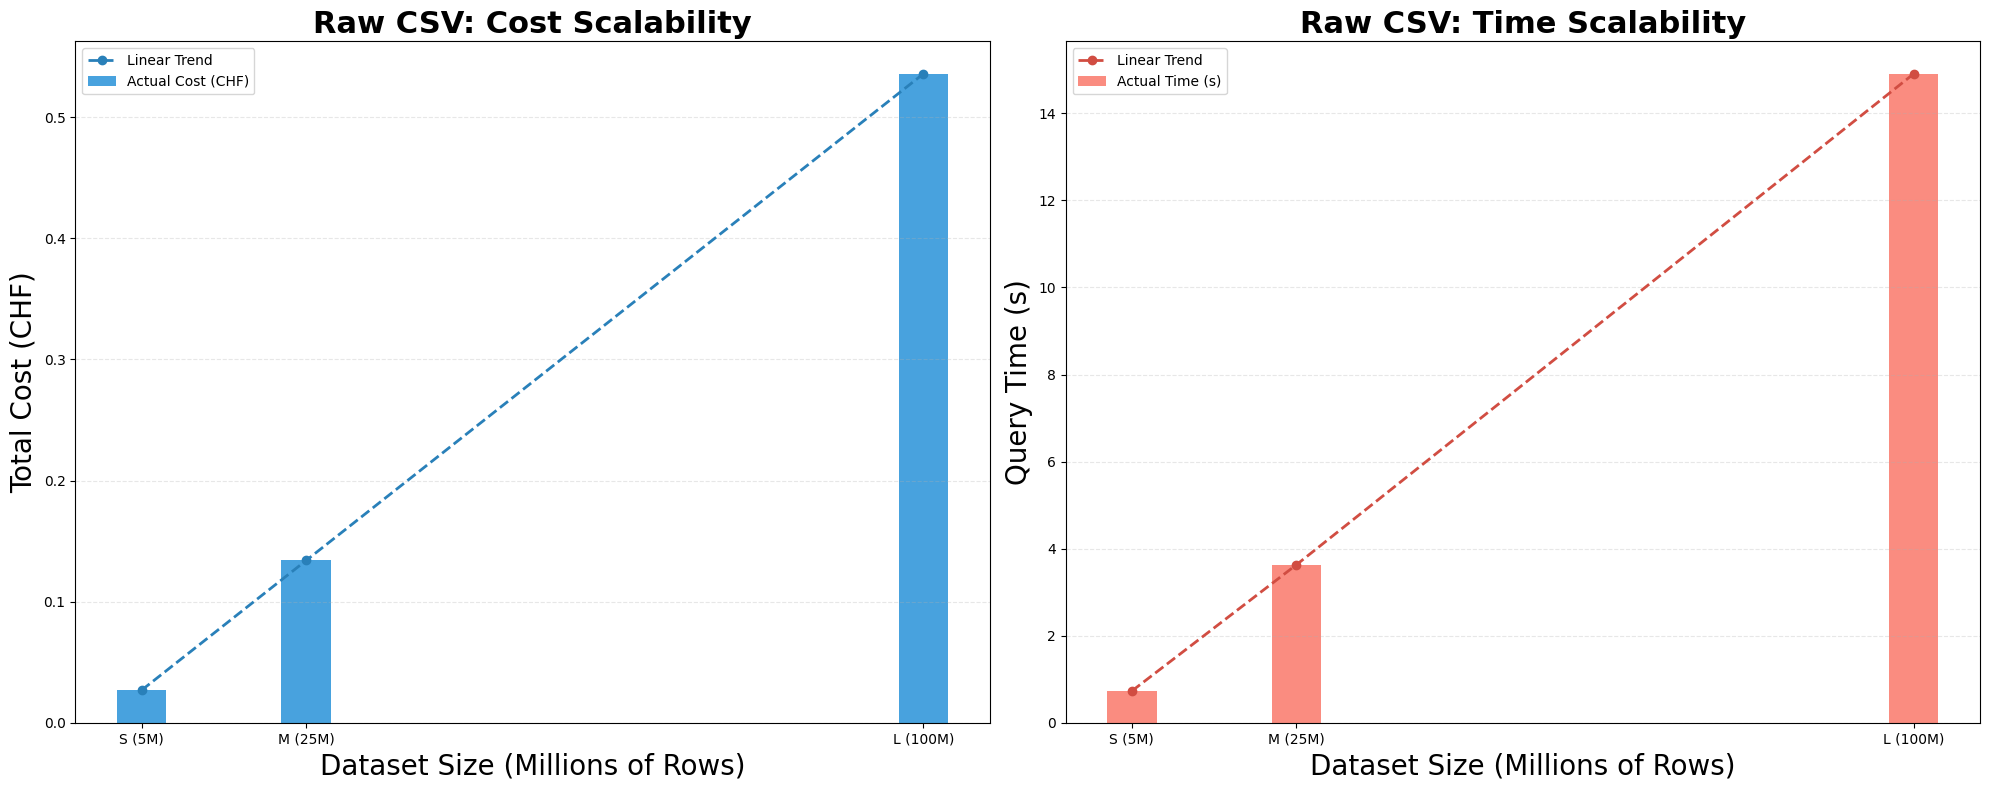

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load data directly from your results to ensure accuracy
df = pd.read_csv('results.csv')

# 2. Graduation settings
row_counts = np.array([5, 25, 100])
labels = ['S (5M)', 'M (25M)', 'L (100M)']
width = 6 # Consistent bar width

# 3. Setup Figure (matching the 20x8 aspect ratio)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Filter for the 'raw' baseline metrics across S, M, L
raw_metrics = df[df['variant'] == 'raw'].set_index('label').reindex(['S', 'M', 'L'])

# --- LEFT PLOT: COST SCALABILITY (Blue Theme) ---
ax1.bar(row_counts, raw_metrics['total_chf'], width, color='#3498db', alpha=0.9, label='Actual Cost (CHF)')
ax1.plot(row_counts, raw_metrics['total_chf'], marker='o', color='#2980b9', linestyle='--', linewidth=2, label='Linear Trend')

ax1.set_title('Raw CSV: Cost Scalability', fontsize=22, fontweight='bold')
ax1.set_ylabel('Total Cost (CHF)', fontsize=20)
ax1.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax1.set_xticks(row_counts)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- RIGHT PLOT: TIME SCALABILITY (Salmon Theme) ---
ax2.bar(row_counts, raw_metrics['query_time_s'], width, color='#fa8072', alpha=0.9, label='Actual Time (s)')
ax2.plot(row_counts, raw_metrics['query_time_s'], marker='o', color='#d14d42', linestyle='--', linewidth=2, label='Linear Trend')

ax2.set_title('Raw CSV: Time Scalability', fontsize=22, fontweight='bold')
ax2.set_ylabel('Query Time (s)', fontsize=20)
ax2.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax2.set_xticks(row_counts)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

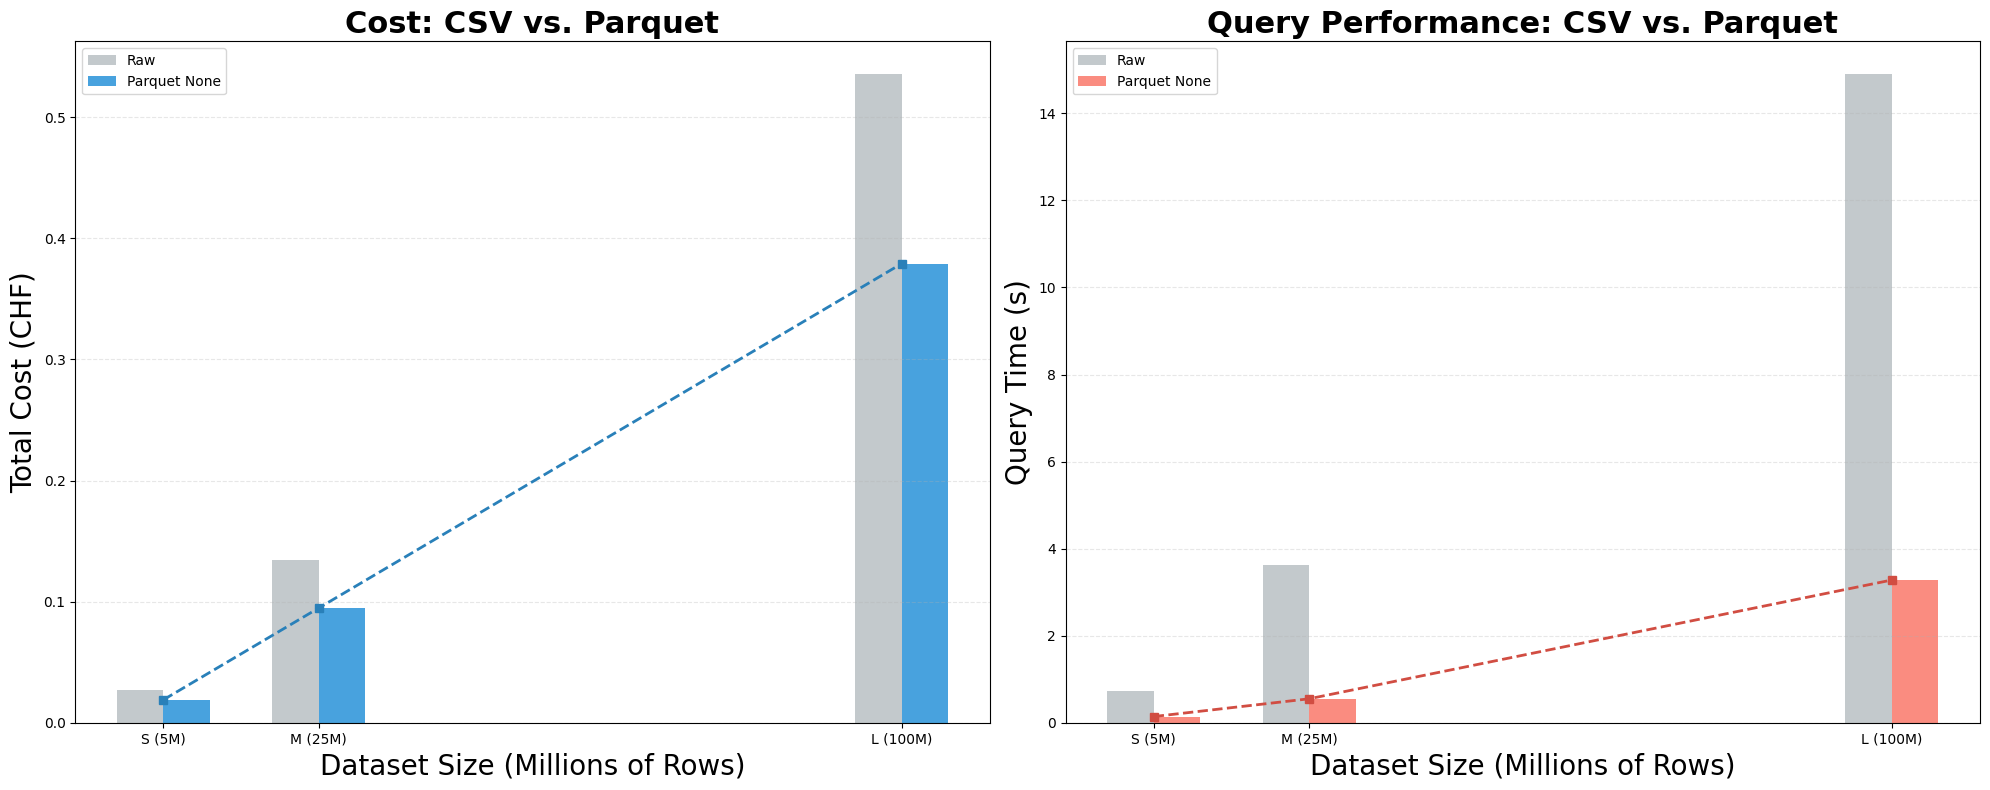

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
df = pd.read_csv('results.csv')

# 2. Naming logic
df['full_variant'] = df.apply(
    lambda x: f"{x['variant']}_{x['compression']}" if pd.notnull(x['compression']) and x['compression'] != '' 
    else x['variant'], axis=1
)

# 3. Settings
row_counts = np.array([5, 25, 100])
labels = ['S (5M)', 'M (25M)', 'L (100M)']
variants = ['raw', 'parquet_none']
left_colors = ['#bdc3c7', '#3498db']  # Gray and Blue for Storage
right_colors = ['#bdc3c7', 'salmon'] # Light Red and Salmon for Time
width = 6 

# 4. Create Figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- LEFT PLOT: STORAGE FOOTPRINT (Blue Theme) ---
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 0.5) * width
    ax1.bar(row_counts + offset, v_data['total_chf'], width, 
            label=variant.replace('_', ' ').title(), color=left_colors[i], alpha=0.9)

# Trend lines for Storage
par_s_trend = df[df['full_variant'] == 'parquet_none'].set_index('label').reindex(['S', 'M', 'L'])['total_chf']
ax1.plot(row_counts, par_s_trend, color='#2980b9', linestyle='--', marker='s', linewidth=2)

ax1.set_title('Cost: CSV vs. Parquet', fontsize=22, fontweight='bold')
ax1.set_ylabel('Total Cost (CHF)', fontsize=20)
ax1.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax1.set_xticks(row_counts)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- RIGHT PLOT: QUERY TIME (Salmon Theme) ---
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 0.5) * width
    ax2.bar(row_counts + offset, v_data['query_time_s'], width, 
            label=variant.replace('_', ' ').title(), color=right_colors[i], alpha=0.9)

# Trend lines for Time
par_t_trend = df[df['full_variant'] == 'parquet_none'].set_index('label').reindex(['S', 'M', 'L'])['query_time_s']
ax2.plot(row_counts, par_t_trend, color='#d14d42', linestyle='--', marker='s', linewidth=2) # Darker salmon trend

ax2.set_title('Query Performance: CSV vs. Parquet', fontsize=22, fontweight='bold')
ax2.set_ylabel('Query Time (s)', fontsize=20)
ax2.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax2.set_xticks(row_counts)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print(f"\nBaseline Metrics: Raw CSV vs Uncompressed Parquet")
print("-" * 95)

# 1. FIX: Wrap conditions in parentheses
# 2. FIX: Use 'full_variant' list for cleaner syntax if preferred
mask = (summary['full_variant'] == "raw") | (summary['full_variant'] == "parquet_none")
size_subset = summary[mask][cols]

# Use to_string with correct justification and formatters
print(size_subset.to_string(
    index=False,
    col_space=[8, 22, 12, 12, 15, 12], # Increased col_space for variant names
    justify='left',
    formatters={
        'total_chf': '{:<10.6f}'.format,         
        'query_time_s': '{:<10.3f}'.format,
        'efficiency_index': '{:<15.6f}'.format,
        'improvement_factor': '{:<15.2f}'.format # Re-added 'x' for readability
    }
))

print("-" * 95)


Baseline Metrics: Raw CSV vs Uncompressed Parquet
-----------------------------------------------------------------------------------------------
label    full_variant           total_chf    query_time_s efficiency_index improvement_factor
L        parquet_none           0.379054     3.279        1.242918         6.43              
L                 raw           0.535903     14.910       7.990314         1.00              
M        parquet_none           0.094780     0.550        0.052129         9.33              
M                 raw           0.133992     3.630        0.486391         1.00              
S        parquet_none           0.018974     0.142        0.002694         7.26              
S                 raw           0.026817     0.729        0.019550         1.00              
-----------------------------------------------------------------------------------------------


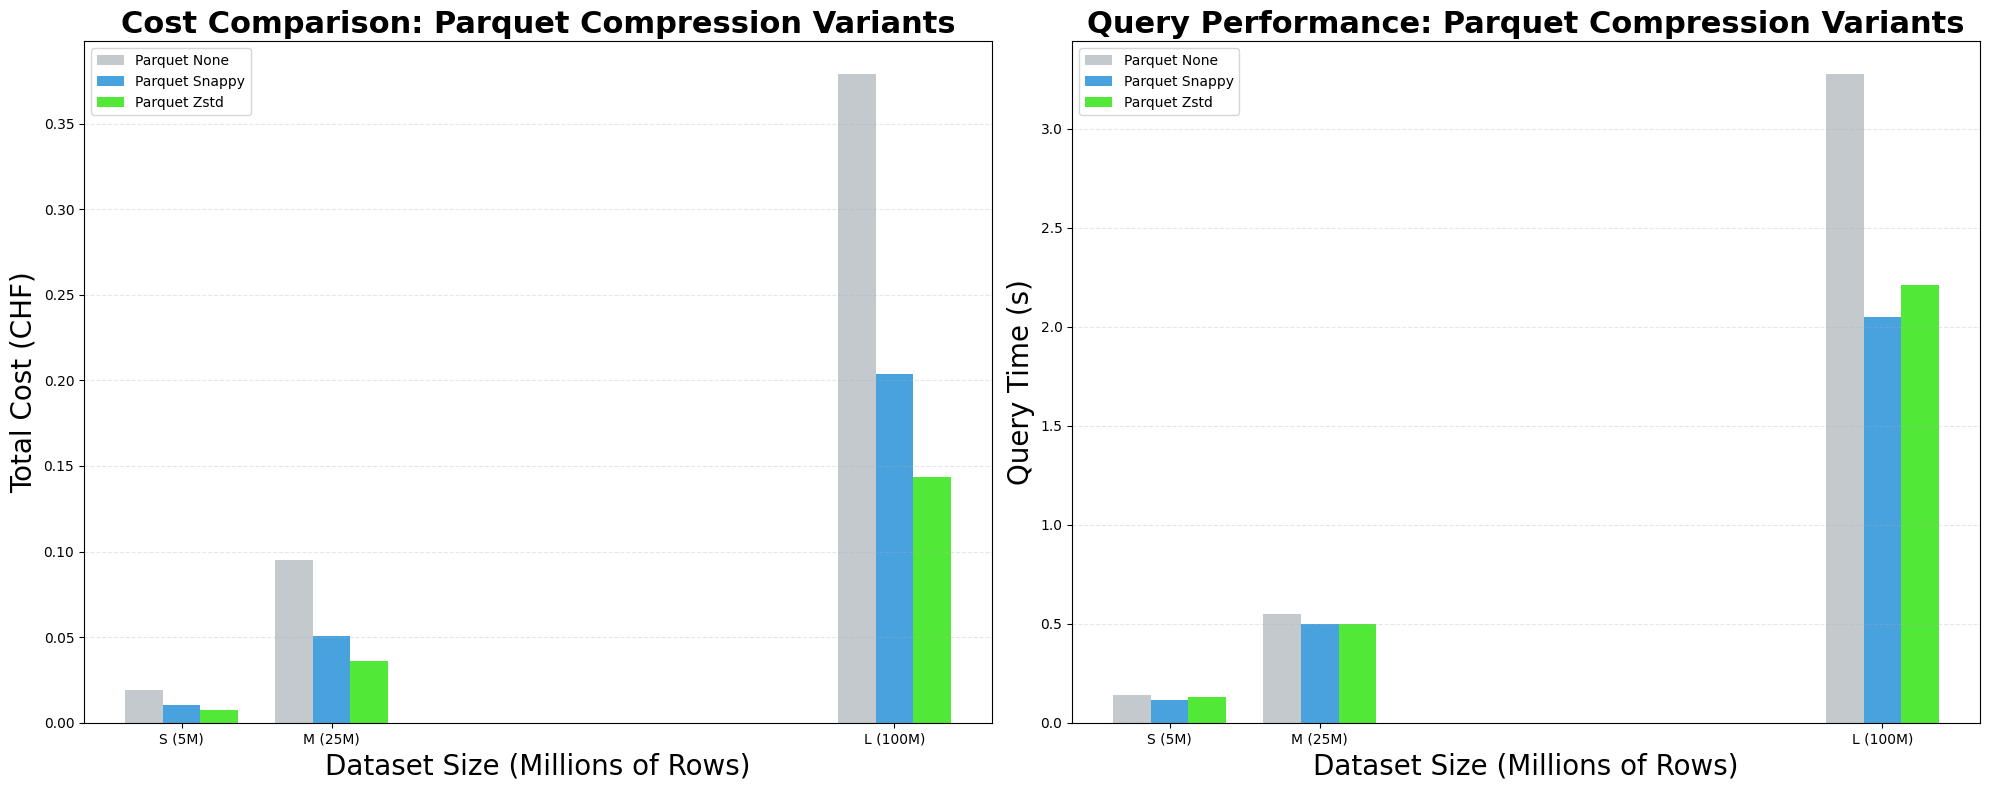

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
df = pd.read_csv('results.csv')

# 2. Naming logic
df['full_variant'] = df.apply(
    lambda x: f"{x['variant']}_{x['compression']}" if pd.notnull(x['compression']) and x['compression'] != '' 
    else x['variant'], axis=1
)

# 3. Settings
row_counts = np.array([5, 25, 100])
labels = ['S (5M)', 'M (25M)', 'L (100M)']
# We are comparing the three Parquet flavors
variants = ['parquet_none', 'parquet_snappy', 'parquet_zstd']

# Professional Palettes
left_colors = ['#bdc3c7', '#3498db', "#3fe622c6"]  # Blue, Green, Orange for Storage
right_colors = ['#bdc3c7', '#3498db', "#3fe622c6"] # Light Salmon to Dark Salmon for Time
width = 5 

# 4. Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- LEFT PLOT: STORAGE FOOTPRINT (Blue/Multi Theme) ---
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 1) * width # Centers the middle bar (Snappy) on the tick
    ax1.bar(row_counts + offset, v_data['total_chf'], width, 
            label=variant.replace('_', ' ').title(), color=left_colors[i], alpha=0.9)

# Trend line for the best performer (Zstd)
zstd_s_trend = df[df['full_variant'] == 'parquet_zstd'].set_index('label').reindex(['S', 'M', 'L'])['total_chf']

ax1.set_title('Cost Comparison: Parquet Compression Variants', fontsize=22, fontweight='bold')
ax1.set_ylabel('Total Cost (CHF)', fontsize=20)
ax1.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax1.set_xticks(row_counts)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- RIGHT PLOT: QUERY TIME (Salmon Theme) ---
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 1) * width
    ax2.bar(row_counts + offset, v_data['query_time_s'], width, 
            label=variant.replace('_', ' ').title(), color=right_colors[i], alpha=0.9)

# Trend line for the best performer (Zstd)
zstd_t_trend = df[df['full_variant'] == 'parquet_zstd'].set_index('label').reindex(['S', 'M', 'L'])['query_time_s']

ax2.set_title('Query Performance: Parquet Compression Variants', fontsize=22, fontweight='bold')
ax2.set_ylabel('Query Time (s)', fontsize=20)
ax2.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax2.set_xticks(row_counts)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
print(f"\nBaseline Metrics: Uncompressed Parquet vs Parquet Snappy vs Parquet Zstd")
print("-" * 95)

# 1. FIX: Wrap conditions in parentheses
# 2. FIX: Use 'full_variant' list for cleaner syntax if preferred
mask = (summary['full_variant'] == "parquet_none") | (summary['full_variant'] == "parquet_snappy")| (summary['full_variant'] == "parquet_zstd")
size_subset = summary[mask][cols]

# Use to_string with correct justification and formatters
print(size_subset.to_string(
    index=False,
    col_space=[8, 22, 12, 12, 15, 12], # Increased col_space for variant names
    justify='left',
    formatters={
        'total_chf': '{:<10.6f}'.format,         
        'query_time_s': '{:<10.3f}'.format,
        'efficiency_index': '{:<15.6f}'.format,
        'improvement_factor': '{:<15.2f}'.format # Re-added 'x' for readability
    }
))

print("-" * 95)


Baseline Metrics: Uncompressed Parquet vs Parquet Snappy vs Parquet Zstd
-----------------------------------------------------------------------------------------------
label    full_variant           total_chf    query_time_s efficiency_index improvement_factor
L          parquet_zstd         0.143375     2.214        0.317432         25.17             
L        parquet_snappy         0.203565     2.048        0.416901         19.17             
L          parquet_none         0.379054     3.279        1.242918         6.43              
M          parquet_zstd         0.035861     0.497        0.017823         27.29             
M        parquet_snappy         0.050908     0.501        0.025505         19.07             
M          parquet_none         0.094780     0.550        0.052129         9.33              
S          parquet_zstd         0.007190     0.128        0.000920         21.24             
S        parquet_snappy         0.010199     0.116        0.001183         16.

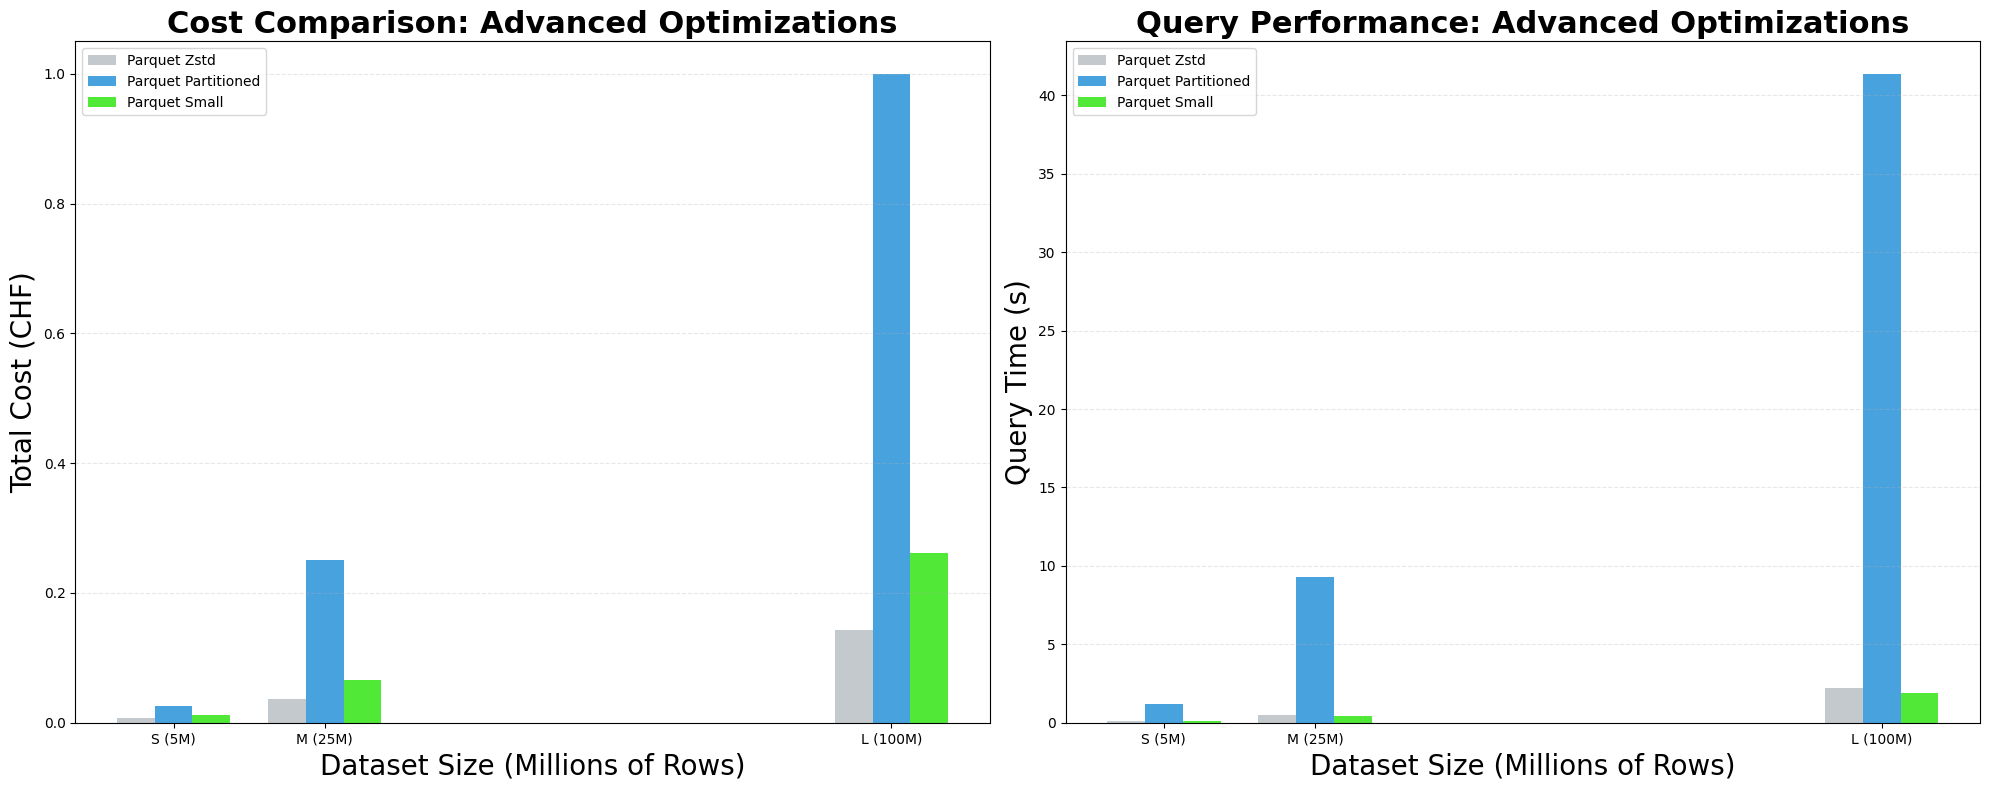

In [47]:

# 2. Naming logic
# Adjust this logic if your partitioned/small variants have specific naming in the CSV
df['full_variant'] = df.apply(
    lambda x: f"{x['variant']}_{x['compression']}" if pd.notnull(x['compression']) and x['compression'] != '' 
    else x['variant'], axis=1
)

# 3. Settings
row_counts = np.array([5, 25, 100])
labels = ['S (5M)', 'M (25M)', 'L (100M)']

# Update these strings to match the exact 'full_variant' names in your results.csv
# e.g., 'parquet_zstd', 'parquet_partitioned', 'parquet_small'
variants = ['parquet_zstd', 'parquet_partitioned', 'parquet_small']

left_colors = ['#bdc3c7', '#3498db', "#3fe622c6"]  # Blue, Purple, Dark Slate
right_colors = ['#bdc3c7', '#3498db', "#3fe622c6"] # Salmon shades
width = 5 

# 4. Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- LEFT PLOT: COST COMPARISON (Blue Theme) ---
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 1) * width
    ax1.bar(row_counts + offset, v_data['total_chf'], width, 
            label=variant.replace('_', ' ').title(), color=left_colors[i], alpha=0.9)

ax1.set_title('Cost Comparison: Advanced Optimizations', fontsize=22, fontweight='bold')
ax1.set_ylabel('Total Cost (CHF)', fontsize=20)
ax1.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax1.set_xticks(row_counts)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- RIGHT PLOT: QUERY TIME COMPARISON (Salmon Theme) ---
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 1) * width
    ax2.bar(row_counts + offset, v_data['query_time_s'], width, 
            label=variant.replace('_', ' ').title(), color=right_colors[i], alpha=0.9)

ax2.set_title('Query Performance: Advanced Optimizations', fontsize=22, fontweight='bold')
ax2.set_ylabel('Query Time (s)', fontsize=20)
ax2.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax2.set_xticks(row_counts)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
print(f"\nBaseline Metrics: Uncompressed Parquet vs Parquet Snappy vs Parquet Zstd")
print("-" * 95)

# 1. FIX: Wrap conditions in parentheses
# 2. FIX: Use 'full_variant' list for cleaner syntax if preferred
mask = (summary['full_variant'] == "parquet_zstd") | (summary['full_variant'] == "parquet_small")| (summary['full_variant'] == "parquet_partitioned")
size_subset = summary[mask][cols]

# Use to_string with correct justification and formatters
print(size_subset.to_string(
    index=False,
    col_space=[8, 22, 12, 12, 15, 12], # Increased col_space for variant names
    justify='left',
    formatters={
        'total_chf': '{:<10.6f}'.format,         
        'query_time_s': '{:<10.3f}'.format,
        'efficiency_index': '{:<15.6f}'.format,
        'improvement_factor': '{:<15.2f}'.format # Re-added 'x' for readability
    }
))

print("-" * 95)


Baseline Metrics: Uncompressed Parquet vs Parquet Snappy vs Parquet Zstd
-----------------------------------------------------------------------------------------------
label    full_variant           total_chf    query_time_s efficiency_index improvement_factor
L               parquet_zstd    0.143375     2.214        0.317432         25.17             
L              parquet_small    0.260996     1.927        0.502939         15.89             
L        parquet_partitioned    1.000281     41.378       41.389627        0.19              
M               parquet_zstd    0.035861     0.497        0.017823         27.29             
M              parquet_small    0.065255     0.452        0.029495         16.49             
M        parquet_partitioned    0.251089     9.288        2.332115         0.21              
S               parquet_zstd    0.007190     0.128        0.000920         21.24             
S              parquet_small    0.012652     0.105        0.001328         14.